In [1]:
import warnings
warnings.filterwarnings('ignore')
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE
 
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("data.csv")          # <-- update path if needed
df.columns = df.columns.str.strip()   # remove leading/trailing spaces from column names
 
print(f"Dataset Shape : {df.shape}")
print(f"\nColumn Names (first 10): {list(df.columns[:10])}")
print(f"\nTarget Variable Distribution:")
print(df['Bankrupt?'].value_counts())
print(f"\nClass Percentages:")
print(df['Bankrupt?'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print(f"\nMissing Values (total): {df.isnull().sum().sum()}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nBasic Statistics:")
df.describe()

Dataset Shape : (6819, 96)

Column Names (first 10): ['Bankrupt?', 'ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Operating Gross Margin', 'Realized Sales Gross Margin', 'Operating Profit Rate', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Non-industry income and expenditure/revenue']

Target Variable Distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Class Percentages:
Bankrupt?
0    96.77%
1     3.23%
Name: proportion, dtype: object

Missing Values (total): 0

Data Types:
float64    93
int64       3
Name: count, dtype: int64

Basic Statistics:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


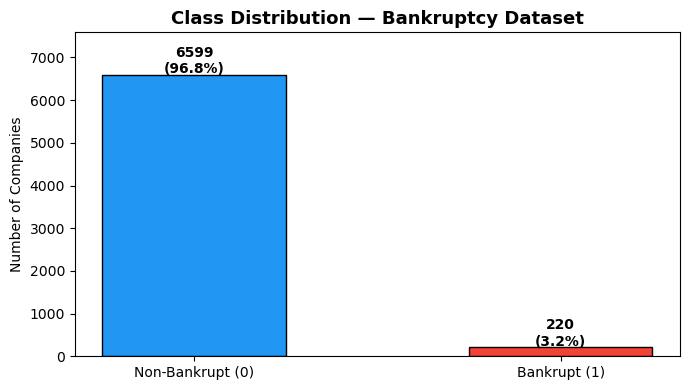

Severe class imbalance detected: ~30:1 ratio (Non-Bankrupt vs Bankrupt)


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['Bankrupt?'].value_counts()
bars = ax.bar(
    ['Non-Bankrupt (0)', 'Bankrupt (1)'],
    counts.values,
    color=['#2196F3', '#F44336'],
    edgecolor='black',
    width=0.5
)
for bar, v in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{v}\n({v / len(df) * 100:.1f}%)',
        ha='center', fontweight='bold'
    )
ax.set_title('Class Distribution — Bankruptcy Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Companies')
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150)
plt.show()
print("Severe class imbalance detected: ~30:1 ratio (Non-Bankrupt vs Bankrupt)")

In [5]:
miss = df.isnull().mean().sort_values(ascending=False)
print(f"Features with any missing values: {(miss > 0).sum()}")
print(f"Max missing rate: {miss.max():.2%}")
 

Features with any missing values: 0
Max missing rate: 0.00%


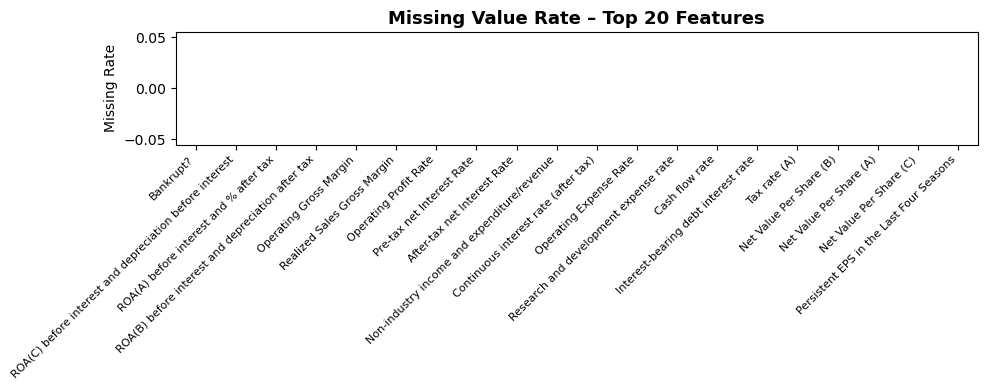

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
miss.head(20).plot(kind='bar', color='#FF7043', ax=ax)
ax.set_title('Missing Value Rate – Top 20 Features', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing Rate')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('02_missing_values.png', dpi=150)
plt.show()
 


In [7]:
# ──  Preprocessing ────────────────────────────────────
# Step 1: Drop columns with > 50% missing (robustness step)
thresh = 0.5
df_clean = df.dropna(thresh=int((1 - thresh) * len(df)), axis=1)
print(f"Shape after dropping high-missing columns: {df_clean.shape}")
 
# Step 2: Fill any remaining missing values with column median
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
 
# Step 3: Clip extreme outliers to 1st–99th percentile
Q1 = df_clean.quantile(0.01)
Q3 = df_clean.quantile(0.99)
df_clean = df_clean.clip(lower=Q1, upper=Q3, axis=1)
 
print(f"Shape after cleaning          : {df_clean.shape}")
print(f"Missing values after cleaning : {df_clean.isnull().sum().sum()}")

Shape after dropping high-missing columns: (6819, 96)
Shape after cleaning          : (6819, 96)
Missing values after cleaning : 0


Top 15 Features by |Pearson Correlation| with Bankruptcy:
Net Income to Stockholder's Equity                         0.346337
Borrowing dependency                                       0.314786
Total debt/Total net worth                                 0.302079
Net Income to Total Assets                                 0.299352
Retained Earnings to Total Assets                          0.282879
Liability to Equity                                        0.278064
ROA(A) before interest and % after tax                     0.265849
ROA(B) before interest and depreciation after tax          0.260157
Continuous interest rate (after tax)                       0.249591
ROA(C) before interest and depreciation before interest    0.249551
Current Liability to Current Assets                        0.247441
Current Liabilities/Equity                                 0.244126
Current Liability to Equity                                0.244126
After-tax net Interest Rate                               

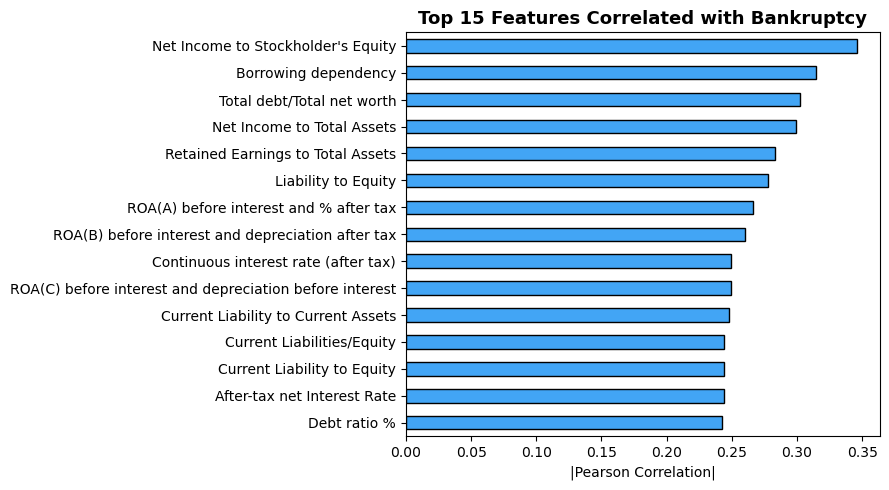

In [8]:
# ──  Feature Correlation with Target ──────────────────
corr = df_clean.corr()['Bankrupt?'].drop('Bankrupt?').abs().sort_values(ascending=False)
top_features = corr.head(15).index.tolist()
 
print("Top 15 Features by |Pearson Correlation| with Bankruptcy:")
print(corr.head(15).to_string())
 
fig, ax = plt.subplots(figsize=(9, 5))
corr.head(15).sort_values().plot(kind='barh', color='#42A5F5', ax=ax, edgecolor='black')
ax.set_title('Top 15 Features Correlated with Bankruptcy', fontsize=13, fontweight='bold')
ax.set_xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.savefig('03_feature_correlation.png', dpi=150)
plt.show()
 

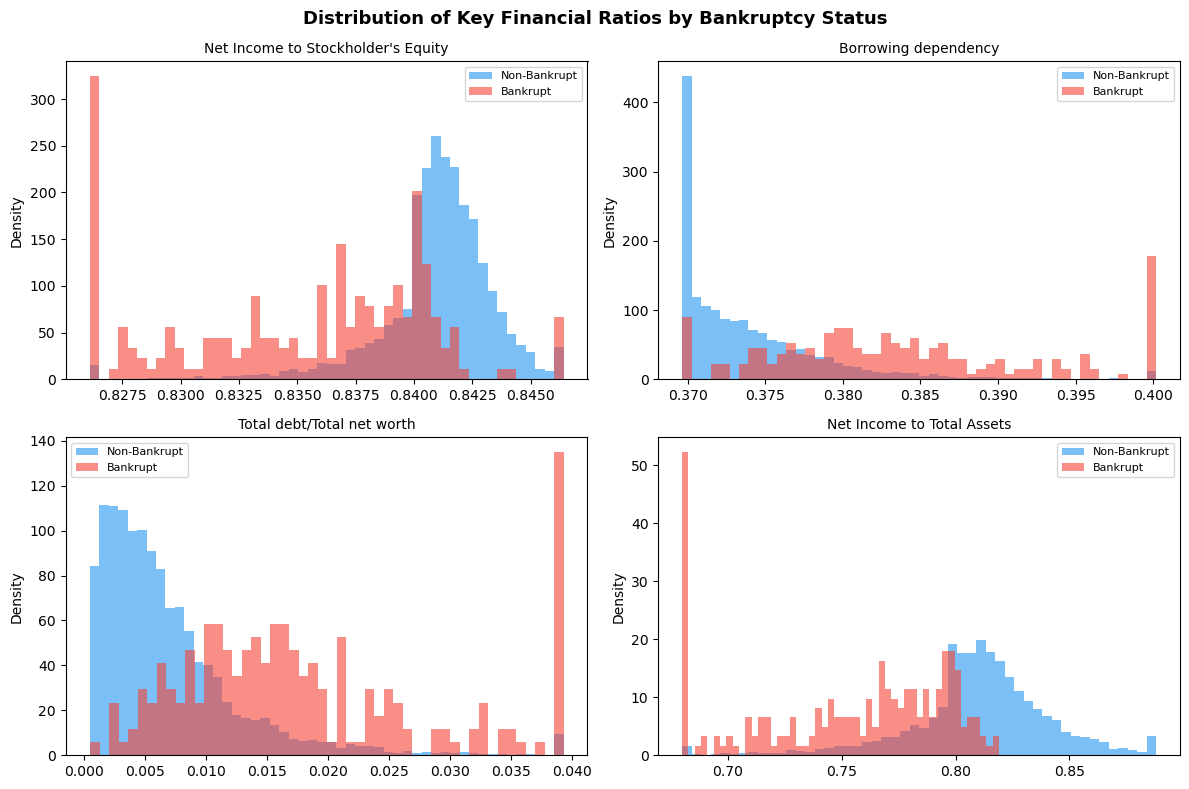

In [9]:
# ──  Distribution of Key Financial Ratios ─────────────
# Use top 4 correlated features for distributions
plot_cols = top_features[:4]
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), plot_cols):
    bankrupt     = df_clean[df_clean['Bankrupt?'] == 1][col]
    non_bankrupt = df_clean[df_clean['Bankrupt?'] == 0][col]
    ax.hist(non_bankrupt, bins=50, alpha=0.6, color='#2196F3', label='Non-Bankrupt', density=True)
    ax.hist(bankrupt,     bins=50, alpha=0.6, color='#F44336', label='Bankrupt',     density=True)
    ax.set_title(col[:50], fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
 
plt.suptitle(
    'Distribution of Key Financial Ratios by Bankruptcy Status',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('04_distributions.png', dpi=150)
plt.show()
 
 

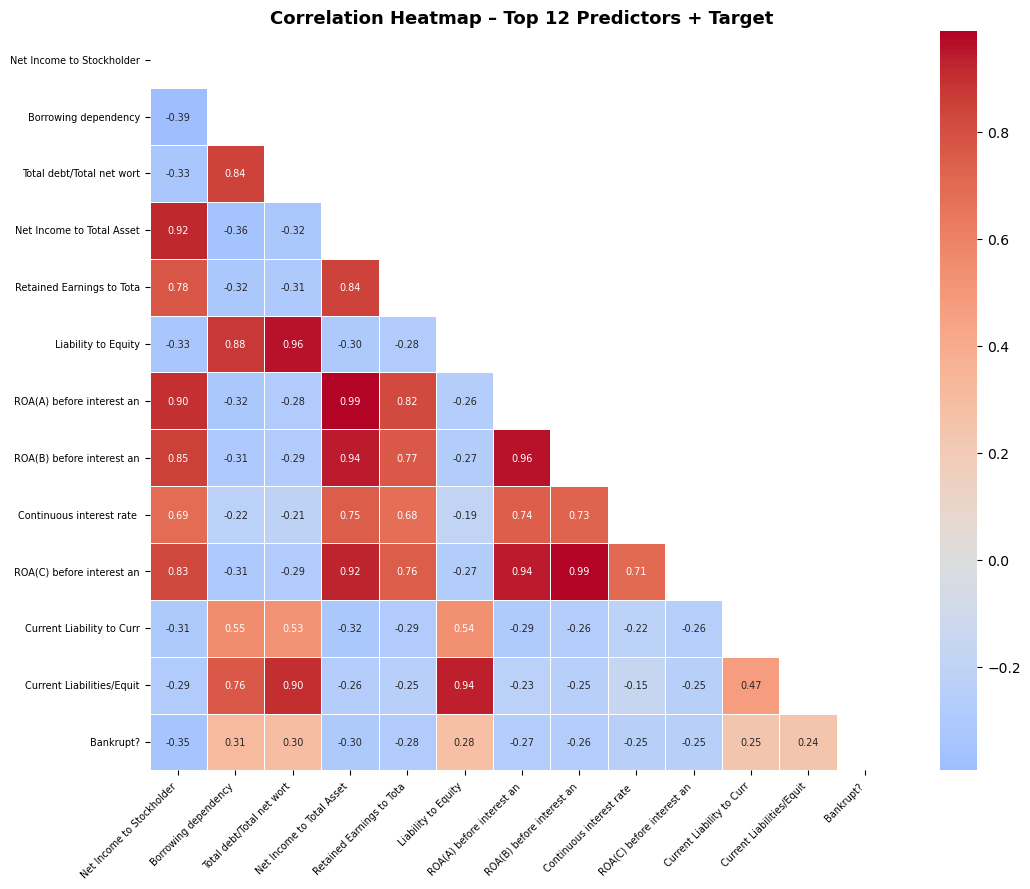

In [11]:
# ── : Correlation Heatmap ──────────────────────────────
top12 = top_features[:12]
 
fig, ax = plt.subplots(figsize=(11, 9))
corr_matrix = df_clean[top12 + ['Bankrupt?']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, annot_kws={'size': 7}
)
ax.set_title('Correlation Heatmap – Top 12 Predictors + Target', fontsize=13, fontweight='bold')
labels = [l[:25] for l in corr_matrix.columns]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(labels, rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150)
plt.show()

In [12]:
# ──  Train / Test Split ───────────────────────────────
X = df_clean.drop('Bankrupt?', axis=1)
y = df_clean['Bankrupt?']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # preserves class ratio in both splits
)
 
print(f"Training set size : {X_train.shape}")
print(f"Test set size     : {X_test.shape}")
print(f"\nTraining target distribution (before SMOTE):")
print(y_train.value_counts())
 

Training set size : (5455, 95)
Test set size     : (1364, 95)

Training target distribution (before SMOTE):
Bankrupt?
0    5279
1     176
Name: count, dtype: int64


In [13]:
# ──  Apply SMOTE to Training Set ─────────────────────
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
 
print("Class distribution AFTER SMOTE:")
print(pd.Series(y_train_res).value_counts())
print(f"\nTraining set size after SMOTE: {X_train_res.shape}")
 
 
# ── CELL 12: Feature Scaling (for Logistic Regression) ───────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)   # fit only on training data
X_test_scaled  = scaler.transform(X_test)            # apply same transform to test
print("Feature scaling applied (StandardScaler)")

Class distribution AFTER SMOTE:
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64

Training set size after SMOTE: (10558, 95)
Feature scaling applied (StandardScaler)


In [14]:
# ──  Train All Four Models ────────────────────────────
# 1. Logistic Regression (L2 regularized, scaled inputs)
lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr.fit(X_train_scaled, y_train_res)
print("Logistic Regression — trained")
 
# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train_res, y_train_res)
print("Decision Tree       — trained")
 
# 3. Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
print("Random Forest       — trained")
 
# 4. Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train_res, y_train_res)
print("Gradient Boosting   — trained")
 
 

Logistic Regression — trained
Decision Tree       — trained
Random Forest       — trained
Gradient Boosting   — trained


In [15]:
# ── Evaluate All Models ─────────────────────────────
models_eval = {
    'Logistic Regression': (lr, X_test_scaled),
    'Decision Tree':       (dt, X_test),
    'Random Forest':       (rf, X_test),
    'Gradient Boosting':   (gb, X_test),
}
 
results = {}
for name, (model, X_eval) in models_eval.items():
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    rep      = classification_report(y_test, y_pred, output_dict=True)
    auc_score = roc_auc_score(y_test, y_proba)
 
    results[name] = {
        'model':       model,
        'y_pred':      y_pred,
        'y_proba':     y_proba,
        'cm':          confusion_matrix(y_test, y_pred),
        'report':      rep,
        'auc':         auc_score,
        'accuracy':    rep['accuracy'],
        'precision_1': rep['1']['precision'],
        'recall_1':    rep['1']['recall'],
        'f1_1':        rep['1']['f1-score'],
    }
 
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  AUC-ROC   : {auc_score:.4f}")
    print(f"  Accuracy  : {rep['accuracy']:.4f}")
    print(f"  Precision (Bankrupt class) : {rep['1']['precision']:.4f}")
    print(f"  Recall    (Bankrupt class) : {rep['1']['recall']:.4f}")
    print(f"  F1-Score  (Bankrupt class) : {rep['1']['f1-score']:.4f}")
    print(f"\nFull Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Bankrupt', 'Bankrupt']))
 
 


  Logistic Regression
  AUC-ROC   : 0.9477
  Accuracy  : 0.8988
  Precision (Bankrupt class) : 0.2202
  Recall    (Bankrupt class) : 0.8409
  F1-Score  (Bankrupt class) : 0.3491

Full Classification Report:
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.90      0.95      1320
    Bankrupt       0.22      0.84      0.35        44

    accuracy                           0.90      1364
   macro avg       0.61      0.87      0.65      1364
weighted avg       0.97      0.90      0.93      1364


  Decision Tree
  AUC-ROC   : 0.7984
  Accuracy  : 0.9084
  Precision (Bankrupt class) : 0.2168
  Recall    (Bankrupt class) : 0.7045
  F1-Score  (Bankrupt class) : 0.3316

Full Classification Report:
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.92      0.95      1320
    Bankrupt       0.22      0.70      0.33        44

    accuracy                           0.91      1364
   macro avg       0.60      0.81      0.64  

In [18]:
# ──  Summary Table ────────────────────────────────────
summary = pd.DataFrame({
    name: {
        'AUC-ROC':   round(results[name]['auc'], 4),
        'Accuracy':  round(results[name]['accuracy'], 4),
        'Precision': round(results[name]['precision_1'], 4),
        'Recall':    round(results[name]['recall_1'], 4),
        'F1-Score':  round(results[name]['f1_1'], 4),
    }
    for name in results
}).T
summary.index.name = 'Model'
print("\n=== MODEL PERFORMANCE SUMMARY ===")
print(summary.to_string())
 


=== MODEL PERFORMANCE SUMMARY ===
                     AUC-ROC  Accuracy  Precision  Recall  F1-Score
Model                                                              
Logistic Regression   0.9477    0.8988     0.2202  0.8409    0.3491
Decision Tree         0.7984    0.9084     0.2168  0.7045    0.3316
Random Forest         0.9421    0.9406     0.3131  0.7045    0.4336
Gradient Boosting     0.9445    0.9487     0.3194  0.5227    0.3966


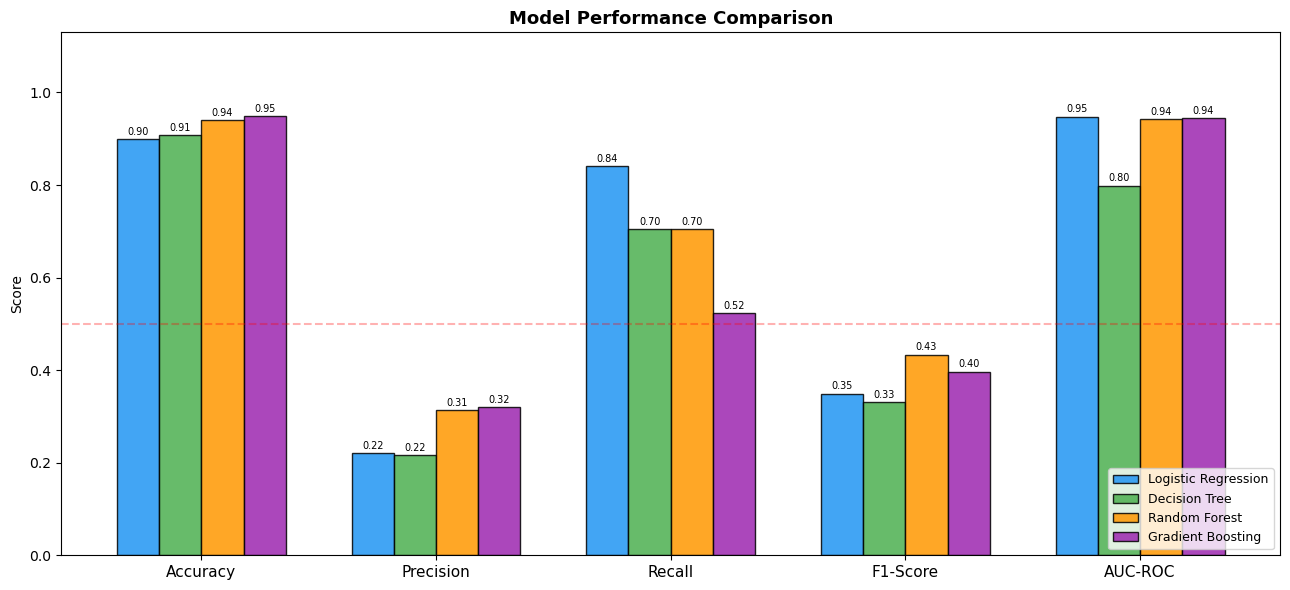

In [19]:
# ── Model Comparison Bar Chart ──────────────────────
metrics     = ['accuracy', 'precision_1', 'recall_1', 'f1_1', 'auc']
labels      = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names = list(results.keys())
colors      = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
 
x     = np.arange(len(metrics))
width = 0.18
 
fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{v:.2f}', ha='center', va='bottom', fontsize=7
        )
 
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.13)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3, label='Random baseline')
plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=150)
plt.show()
 

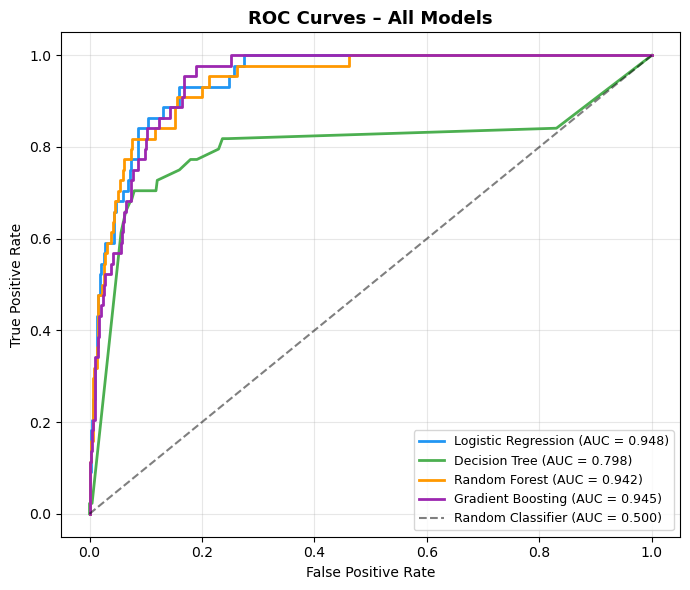

In [20]:
# ──  ROC Curves ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    auc_v = results[name]['auc']
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc_v:.3f})")
 
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('07_roc_curves.png', dpi=150)
plt.show()

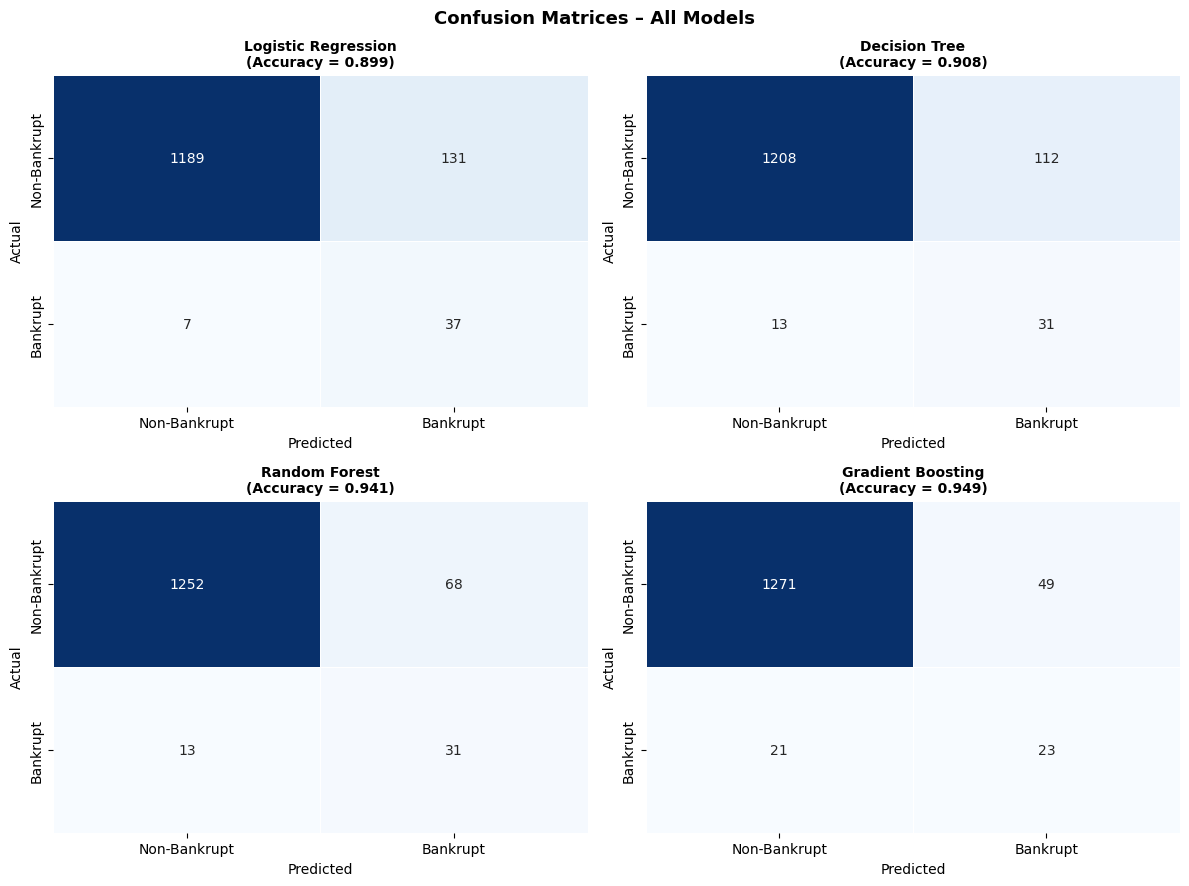

In [21]:
# ──  Confusion Matrices ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, color) in zip(axes.flatten(), zip(model_names, colors)):
    cm = results[name]['cm']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Non-Bankrupt', 'Bankrupt'],
        yticklabels=['Non-Bankrupt', 'Bankrupt'],
        linewidths=0.5, cbar=False
    )
    acc = results[name]['accuracy']
    ax.set_title(f'{name}\n(Accuracy = {acc:.3f})', fontsize=10, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
 
plt.suptitle('Confusion Matrices – All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08_confusion_matrices.png', dpi=150)
plt.show()

Top 15 Most Important Features (Random Forest):
Total debt/Total net worth                           0.071598
Borrowing dependency                                 0.062175
After-tax net Interest Rate                          0.061078
Net Income to Total Assets                           0.055289
Continuous interest rate (after tax)                 0.054159
Persistent EPS in the Last Four Seasons              0.051259
Retained Earnings to Total Assets                    0.040002
Net Income to Stockholder's Equity                   0.038605
Liability to Equity                                  0.029785
ROA(B) before interest and depreciation after tax    0.026961
Debt ratio %                                         0.024538
Net profit before tax/Paid-in capital                0.022947
Net worth/Assets                                     0.021306
Pre-tax net Interest Rate                            0.020282
Current Liability to Equity                          0.018599


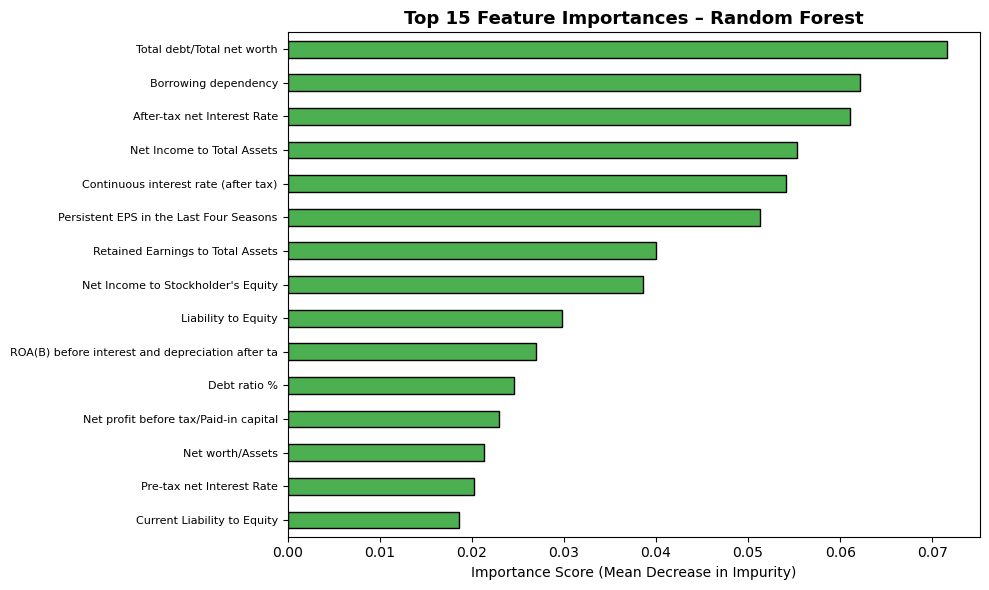

In [22]:
# ── Feature Importance (Random Forest) ──────────────
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
 
top15_importance = importances.head(15)
print("Top 15 Most Important Features (Random Forest):")
print(top15_importance.to_string())
 
fig, ax = plt.subplots(figsize=(10, 6))
top15_importance.sort_values().plot(kind='barh', color='#4CAF50', ax=ax, edgecolor='black')
ax.set_title('Top 15 Feature Importances – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)')
labels_short = [l[:48] for l in top15_importance.sort_values().index]
ax.set_yticklabels(labels_short, fontsize=8)
plt.tight_layout()
plt.savefig('09_feature_importance.png', dpi=150)
plt.show()
 
 

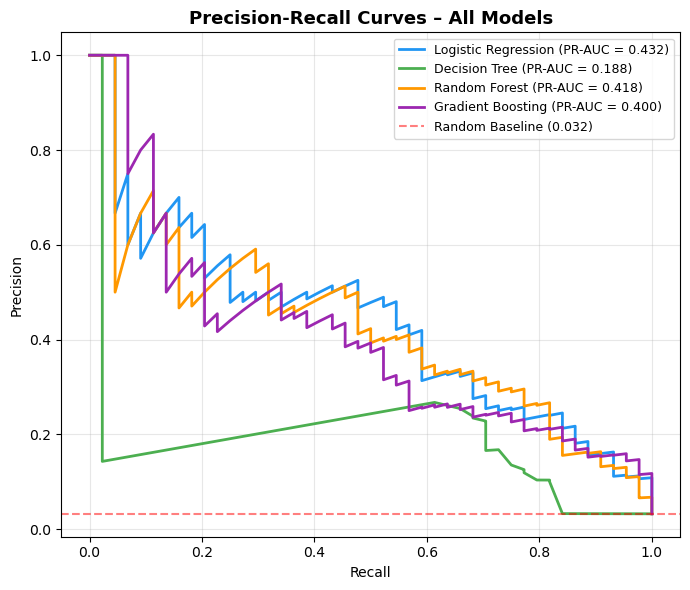

In [23]:
# ── Precision-Recall Curves ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(model_names, colors):
    prec, rec, _ = precision_recall_curve(y_test, results[name]['y_proba'])
    pr_auc = auc(rec, prec)
    ax.plot(rec, prec, color=color, lw=2, label=f"{name} (PR-AUC = {pr_auc:.3f})")
 
baseline = y_test.mean()
ax.axhline(baseline, color='red', linestyle='--', alpha=0.5,
           label=f'Random Baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves – All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('10_pr_curves.png', dpi=150)
plt.show()
 

Random Forest:
  Fold AUCs : [np.float64(0.9114), np.float64(0.9543), np.float64(0.9476), np.float64(0.9086), np.float64(0.9627)]
  Mean AUC  : 0.9369
  Std AUC   : 0.0225

Gradient Boosting:
  Fold AUCs : [np.float64(0.9175), np.float64(0.9484), np.float64(0.9383), np.float64(0.923), np.float64(0.9526)]
  Mean AUC  : 0.9360
  Std AUC   : 0.0138



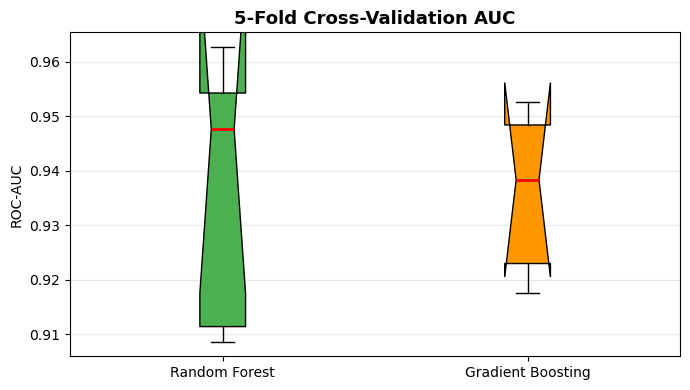

In [24]:
# ──  Cross-Validation (Top 2 Models) ─────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
 
for name, model in [('Random Forest', rf), ('Gradient Boosting', gb)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Fold AUCs : {[round(s, 4) for s in scores]}")
    print(f"  Mean AUC  : {scores.mean():.4f}")
    print(f"  Std AUC   : {scores.std():.4f}\n")
 
# Boxplot of CV scores
fig, ax = plt.subplots(figsize=(7, 4))
data_cv = [cv_results['Random Forest'], cv_results['Gradient Boosting']]
bp = ax.boxplot(data_cv, patch_artist=True, notch=True,
                medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#FF9800')
ax.set_xticklabels(['Random Forest', 'Gradient Boosting'])
ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold Cross-Validation AUC', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('11_cross_validation.png', dpi=150)
plt.show()
 
 